# Задание 2. Статистика Fortnite



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", palette="colorblind", font="DejaVu Sans")
plt.rcParams.update({"figure.figsize": (11, 5.5)})

fortnite = pd.read_csv("datasets/Fortnite Statistics.csv")
fortnite["Accuracy"] = fortnite["Accuracy"].str.rstrip("%").astype(float)


Количество матчей: 87
Пропуски: 0
Полные дубликаты: 0


Для сравнения разделим матчи по итоговому месту: **1–10**, **11–25**, **26 и ниже**.
В группах разное число матчей, поэтому сравниваем средние значения и распределения, а не суммы.

In [2]:
groups = ["1–10 место", "11–25 место", "26 место и ниже"]
fortnite["result_group"] = pd.cut(
    fortnite["Placed"], bins=[0, 10, 25, np.inf], labels=groups
)

palette = dict(zip(groups, sns.color_palette("colorblind", 3)))
group_counts = fortnite["result_group"].value_counts().reindex(groups)
group_labels = [f"{group}\n(n = {group_counts[group]})" for group in groups]

group_counts.rename("Количество матчей").to_frame()

,Количество матчей
result_group,
1–10 место,16
11–25 место,42
26 место и ниже,29


## 1. В удачных матчах больше устранений?

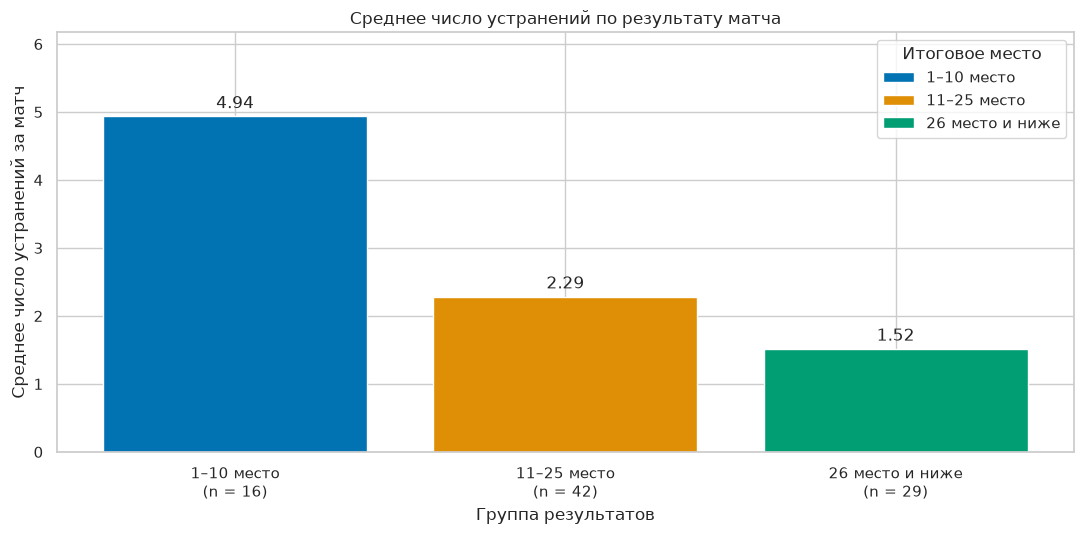

In [3]:
mean_eliminations = (
    fortnite.groupby("result_group", observed=True)["Eliminations"].mean()
)

plt.figure()
bars = plt.bar(
    group_labels,
    mean_eliminations.reindex(groups),
    color=list(palette.values())
)
plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Среднее число устранений по результату матча")
plt.xlabel("Группа результатов")
plt.ylabel("Среднее число устранений за матч")
plt.ylim(0, mean_eliminations.max() * 1.25)
plt.legend(bars, groups, title="Итоговое место")
plt.tight_layout()
plt.show()

**Вывод:** сравниваем среднее число устранений в трёх группах.
В топ-10 оно равно **4,94**, на 11–25 местах — **2,29**, на 26 месте и ниже — **1,52**.
В этой выборке хорошие места сопровождаются большим числом устранений, но это не доказывает, что именно устранения стали причиной результата.

## 2. В удачных матчах выше точность?

Сравним, какая точность встречается чаще в каждой группе. Шкалы и интервалы одинаковые.
По вертикали — доля матчей в группе: так можно сравнивать группы разного размера.
Пунктир показывает среднюю точность.

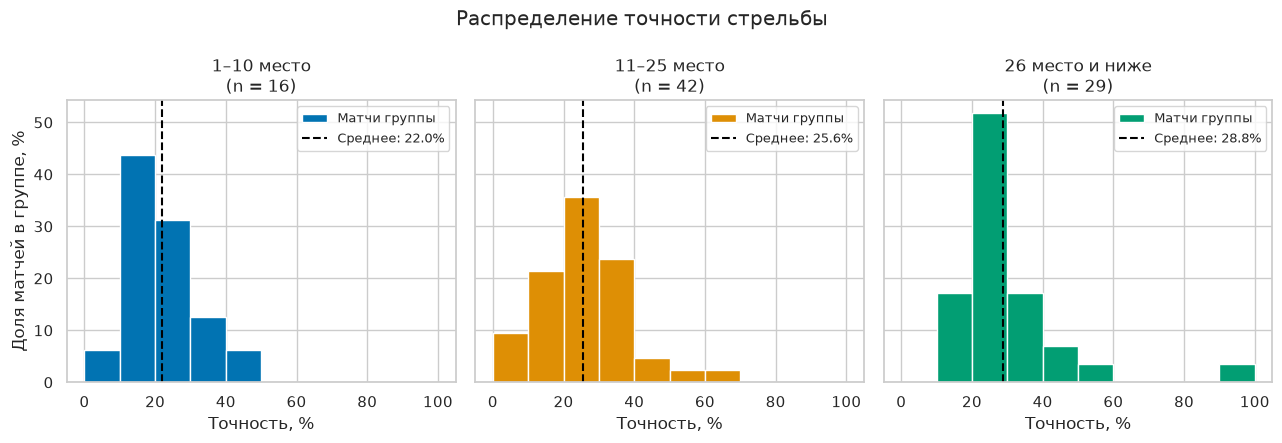

In [4]:
accuracy_bins = np.arange(0, 101, 10)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True)

for ax, group, label in zip(axes, groups, group_labels):
    accuracy = fortnite.loc[fortnite["result_group"] == group, "Accuracy"]
    weights = np.full(len(accuracy), 100 / len(accuracy))
    mean_accuracy = accuracy.mean()

    ax.hist(accuracy, bins=accuracy_bins, weights=weights,
            color=palette[group], edgecolor="white", label="Матчи группы")
    ax.axvline(mean_accuracy, color="black", linestyle="--",
               label=f"Среднее: {mean_accuracy:.1f}%")
    ax.set_title(label)
    ax.set_xlabel("Точность, %")
    ax.set_xticks(range(0, 101, 20))
    ax.legend(fontsize=9)

axes[0].set_ylabel("Доля матчей в группе, %")
fig.suptitle("Распределение точности стрельбы")
plt.tight_layout()
plt.show()

**Вывод:** высота столбца показывает, какой процент матчей группы попал в интервал точности.
Например, столбец 20–30% включает точность от 20% до менее 30%.
Каждый матч даёт одинаковый вклад внутри своей группы.

Средняя точность в топ-10 — **22,0%**, на 11–25 местах — **25,6%**, на 26 месте и ниже — **28,8%**.
Распределения пересекаются: похожая точность встречается при разных итоговых местах.
Значит, большее число устранений в успешных матчах не сопровождается большей средней точностью.
Это среднее процентов по матчам, а не общая точность всех выстрелов.

## 3. Как пройденное расстояние связано с итоговым местом?

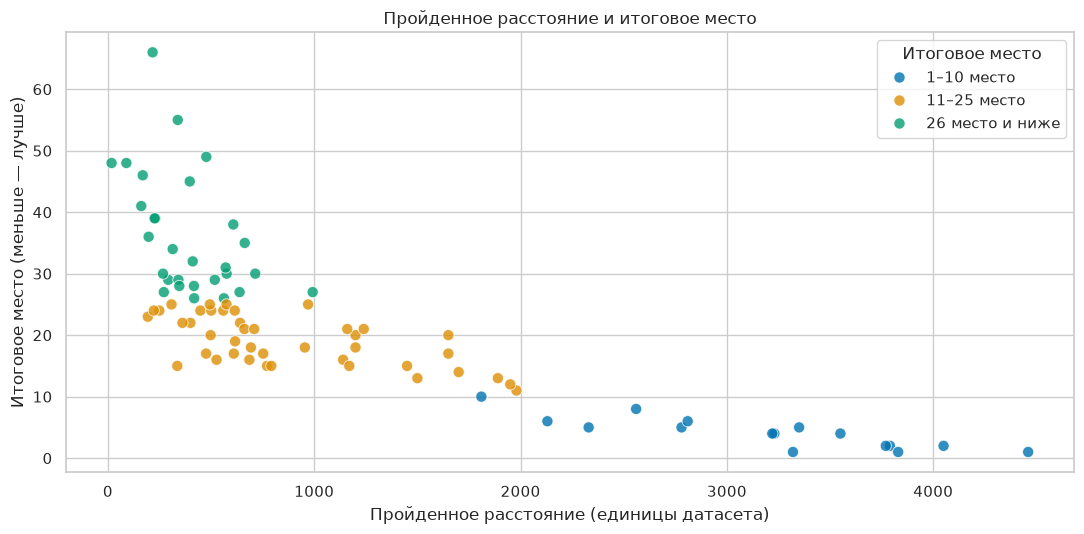

In [5]:
plt.figure()
sns.scatterplot(
    data=fortnite, x="Distance Traveled", y="Placed",
    hue="result_group", hue_order=groups, palette=palette,
    s=65, alpha=0.8
)
plt.title("Пройденное расстояние и итоговое место")
plt.xlabel("Пройденное расстояние (единицы датасета)")
plt.ylabel("Итоговое место (меньше — лучше)")
plt.legend(title="Итоговое место")
plt.tight_layout()
plt.show()

**Вывод:** каждая точка — один матч. Справа, при больших расстояниях, точки в основном
расположены ниже — это лучшие итоговые места.
Возможное объяснение: игрок дольше остаётся в матче и успевает больше пройти.
График не доказывает, что само перемещение улучшает результат; единица расстояния в CSV не указана.

## 4. Как различаются сбор и использование материалов?

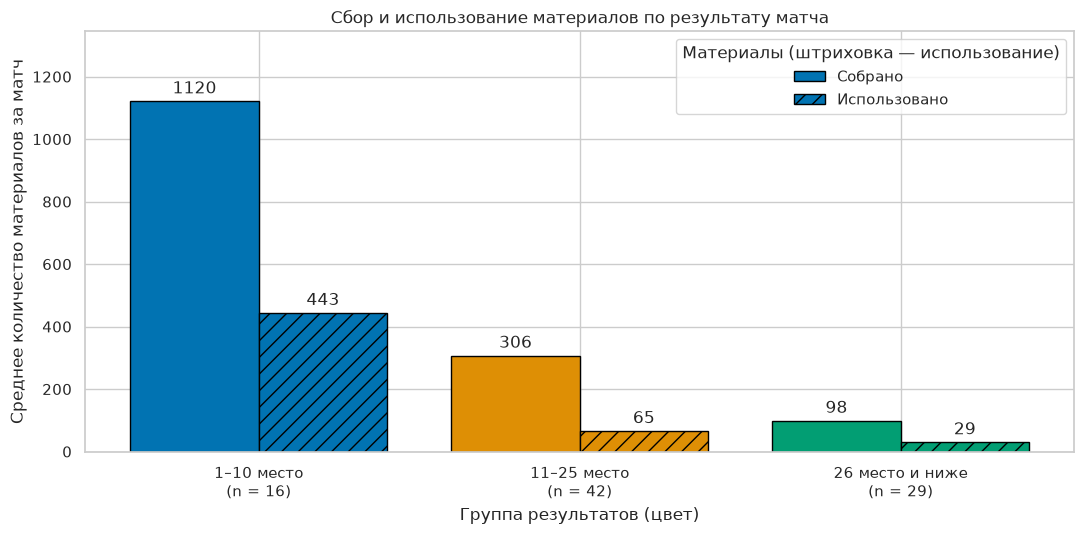

In [6]:
mean_materials = (
    fortnite.groupby("result_group", observed=True)[
        ["Materials Gathered", "Materials Used"]
    ].mean()
)

positions = np.arange(len(groups))
colors = [palette[group] for group in groups]

plt.figure()
gathered_bars = plt.bar(
    positions - 0.2, mean_materials["Materials Gathered"], width=0.4,
    color=colors, edgecolor="black", label="Собрано"
)
used_bars = plt.bar(
    positions + 0.2, mean_materials["Materials Used"], width=0.4,
    color=colors, edgecolor="black", hatch="//", label="Использовано"
)
plt.bar_label(gathered_bars, fmt="%.0f", padding=3)
plt.bar_label(used_bars, fmt="%.0f", padding=3)
plt.xticks(positions, group_labels)
plt.title("Сбор и использование материалов по результату матча")
plt.xlabel("Группа результатов (цвет)")
plt.ylabel("Среднее количество материалов за матч")
plt.ylim(0, mean_materials.to_numpy().max() * 1.2)
plt.legend(title="Материалы (штриховка — использование)")
plt.tight_layout()
plt.show()

**Вывод:** пары столбцов показывают среднее количество собранных и использованных материалов.
Цвет обозначает группу результатов, штриховка — использованные материалы.
В топ-10 в среднем собрано **1120**, использовано **443**; на 26 месте и ниже — **98** и **29**.
Во всех группах в среднем собирают больше, чем используют.
Большие значения в топ-10 могут быть связаны с более долгим участием в матче, а не только со стилем игры.

## Итог

В матчах с попаданием в топ-10 в среднем больше устранений, собранных и использованных материалов.
При этом средняя точность ниже, чем в двух других группах: больше устранений не обязательно означает более точную стрельбу.
Большие пройденные расстояния также чаще встречаются при лучших местах.
Возможно, часть различий связана с тем, что успешные матчи длятся дольше, но длительности в таблице нет.
Эти наблюдения описывают 87 матчей и не являются рецептом победы.